Loaded shoreline_df: (4804393, 27)
Loaded transects   : (12126, 13)
Loaded stats       : (12126, 37)
Prepared shoreline obs: (4804393, 11)

Coordinate ranges (should look like lon/lat):
start_x: -97.37954 -93.83873
start_y: 25.957376 29.685127
shore_x: -97.379364 -93.83834
shore_y: 25.957218 29.684875
Wrote: F:\crs\proj\2026_shoreline_analysis\TX_baseline.geojson
Wrote: F:\crs\proj\2026_shoreline_analysis\TX_shoreline.geojson


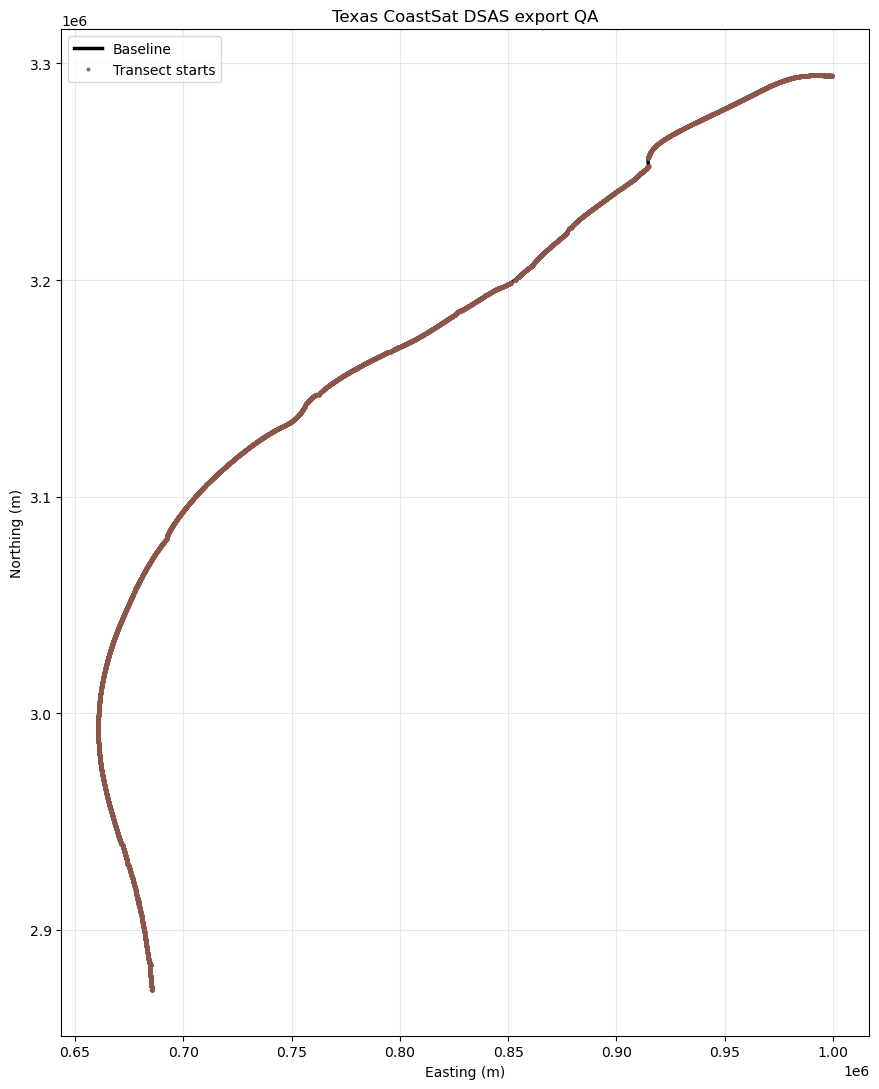

Wrote: F:\crs\proj\2026_shoreline_analysis\TX_DSAS_export_QA.png

Baseline summary
   FID  Id                Attribute     Shape_Leng  \
0    0   1  Texas CoastSat baseline  618128.613869   

                                            geometry  
0  LINESTRING (999731.406 3294427.367, 999689.235...  

Shoreline summary
   FID  FID_       Date_  Uncy  Year_                  Attribute  Shape_Leng  \
0    0     0  03/28/1984  10.0   1984  Texas CoastSat shorelines   98.171644   
1    1     1  03/28/1984  10.0   1984  Texas CoastSat shorelines  491.967905   
2    2     2  03/28/1984  10.0   1984  Texas CoastSat shorelines  540.454063   
3    3     3  03/28/1984  10.0   1984  Texas CoastSat shorelines  441.755793   
4    4     4  03/28/1984  10.0   1984  Texas CoastSat shorelines  147.366114   

                                            geometry  
0  LINESTRING (930059.053 3269389.225, 930016.223...  
1  LINESTRING (929842.326 3269274.047, 929796.299...  
2  LINESTRING (929141.021 3268922

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString


# ============================================================
# INPUT / OUTPUT SETTINGS
# ============================================================
PROCESSED_DIR = Path("F:/crs/proj/2026_shoreline_analysis/processed")
PREFIX = "tx_shoreline"
FORMAT = "parquet"   # "parquet" or "csv"

# shoreline_x / shoreline_y and lon_mid / lat_mid are lon/lat
CRS_GEO = "EPSG:4326"

# DSAS export CRS
CRS_OUT = "EPSG:32614"   # UTM Zone 14N

OUT_DIR = Path("F:/crs/proj/2026_shoreline_analysis")
BASELINE_GEOJSON = OUT_DIR / "TX_baseline.geojson"
SHORELINE_GEOJSON = OUT_DIR / "TX_shoreline.geojson"
QA_PNG = OUT_DIR / "TX_DSAS_export_QA.png"

BASELINE_ATTRIBUTE = "Texas CoastSat baseline"
SHORELINE_ATTRIBUTE = "Texas CoastSat shorelines"
DEFAULT_UNCY_M = 10.0
MIN_POINTS_PER_SHORELINE = 2


# ============================================================
# I/O
# ============================================================
def load_processed_tables(
    out_dir: str | Path,
    prefix: str = "tx_shoreline",
    format: str = "parquet",
):
    out_dir = Path(out_dir)

    if format == "parquet":
        shoreline_df = pd.read_parquet(out_dir / f"{prefix}_obs.parquet")
        transects = pd.read_parquet(out_dir / f"{prefix}_transects.parquet")
        stats = pd.read_parquet(out_dir / f"{prefix}_stats.parquet")
    elif format == "csv":
        shoreline_df = pd.read_csv(out_dir / f"{prefix}_obs.csv", parse_dates=["datetime"])
        transects = pd.read_csv(out_dir / f"{prefix}_transects.csv")
        stats = pd.read_csv(out_dir / f"{prefix}_stats.csv")
    else:
        raise ValueError("format must be 'parquet' or 'csv'")

    return shoreline_df, transects, stats


# ============================================================
# HELPERS
# ============================================================
def choose_col(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"None of these columns were found: {candidates}")
    return None


def prep_shoreline_df(df):
    """
    Standardize shoreline dataframe.

    Assumes:
      shoreline_x, shoreline_y are lon/lat in EPSG:4326
      transect start columns are also lon/lat
    """
    out = df.copy()

    if "datetime" not in out.columns:
        raise KeyError("shoreline_df must contain 'datetime'")

    out["datetime"] = pd.to_datetime(out["datetime"])

    colmap = {
        "start_x": choose_col(out, ["transectStart_X_x", "transectStart_X_y", "transectStart_X"]),
        "start_y": choose_col(out, ["transectStart_Y_x", "transectStart_Y_y", "transectStart_Y"]),
        "shore_x": choose_col(out, ["shoreline_x"]),
        "shore_y": choose_col(out, ["shoreline_y"]),
        "id": choose_col(out, ["ID"]),
        "coast_order": choose_col(out, ["coast_order"]),
    }

    out = out.rename(
        columns={
            colmap["start_x"]: "start_x",
            colmap["start_y"]: "start_y",
            colmap["shore_x"]: "shore_x",
            colmap["shore_y"]: "shore_y",
            colmap["id"]: "transect_id",
            colmap["coast_order"]: "coast_order_std",
        }
    )

    keep = [
        "datetime",
        "transect_id",
        "coast_order_std",
        "start_x",
        "start_y",
        "shore_x",
        "shore_y",
    ]
    for c in ["distance", "year", "s_m", "s_km"]:
        if c in out.columns:
            keep.append(c)

    out = out[keep].copy()
    out = out.dropna(subset=["shore_x", "shore_y", "coast_order_std"])

    return out


def build_baseline_from_transect_starts(shoreline_df_std):
    """
    Build baseline from transect start points in lon/lat.
    """
    pts = (
        shoreline_df_std[["transect_id", "coast_order_std", "start_x", "start_y"]]
        .drop_duplicates(subset=["transect_id"])
        .sort_values(["coast_order_std", "transect_id"])
        .dropna(subset=["start_x", "start_y"])
        .copy()
    )

    xy = pts[["start_x", "start_y"]].to_numpy()

    if len(xy) < 2:
        raise ValueError("Need at least 2 transect start points to build a baseline.")

    geom = LineString(xy)

    gdf = gpd.GeoDataFrame(
        {
            "FID": [0],
            "Id": [1],
            "Attribute": [BASELINE_ATTRIBUTE],
        },
        geometry=[geom],
        crs=CRS_GEO,
    )

    return gdf, pts


def build_shoreline_lines_segmented(
    shoreline_df_std,
    default_uncy_m=10.0,
    min_points=2,
    max_transect_gap=2,
):
    """
    Build shoreline LineStrings for each datetime, splitting into separate
    segments whenever adjacent occupied transects are more than
    `max_transect_gap` apart in coast_order.

    Parameters
    ----------
    shoreline_df_std : DataFrame
        Standardized shoreline observation table. Must contain:
        datetime, transect_id, coast_order_std, shore_x, shore_y
    default_uncy_m : float
        Default uncertainty written to Uncy.
    min_points : int
        Minimum number of points required to create a LineString segment.
    max_transect_gap : int
        Maximum allowed jump in coast_order between adjacent connected points.
        If the gap is greater than this, start a new shoreline segment.

    Returns
    -------
    GeoDataFrame
        One LineString feature per shoreline segment.
    """
    rows = []
    geoms = []
    fid = 0

    df = shoreline_df_std.sort_values(["datetime", "coast_order_std", "transect_id"]).copy()

    for dt, g in df.groupby("datetime", sort=True):
        gg = g.dropna(subset=["shore_x", "shore_y", "coast_order_std"]).copy()
        gg = gg.sort_values(["coast_order_std", "transect_id"])

        # one point per transect per date
        gg = gg.drop_duplicates(subset=["transect_id"], keep="first").copy()

        if len(gg) < min_points:
            continue

        # split into contiguous segments based on coast_order gaps
        segments = []
        current_idx = [gg.index[0]]

        coast_vals = gg["coast_order_std"].to_numpy()

        for i in range(1, len(gg)):
            gap = coast_vals[i] - coast_vals[i - 1]

            if gap <= max_transect_gap:
                current_idx.append(gg.index[i])
            else:
                segments.append(gg.loc[current_idx].copy())
                current_idx = [gg.index[i]]

        # append final segment
        if current_idx:
            segments.append(gg.loc[current_idx].copy())

        # build LineString for each segment
        segno = 0
        for seg in segments:
            if len(seg) < min_points:
                continue

            xy = seg[["shore_x", "shore_y"]].to_numpy()
            geom = LineString(xy)

            rows.append(
                {
                    "FID": int(fid),
                    "FID_": int(fid),
                    "Date_": pd.Timestamp(dt).strftime("%m/%d/%Y"),
                    "Uncy": float(default_uncy_m),
                    "Year_": int(pd.Timestamp(dt).year),
                    "Attribute": SHORELINE_ATTRIBUTE,
                    "datetime": pd.Timestamp(dt),
                    "seg_id": int(segno),
                    "n_pts": int(len(seg)),
                    "coast_min": int(seg["coast_order_std"].min()),
                    "coast_max": int(seg["coast_order_std"].max()),
                }
            )
            geoms.append(geom)

            fid += 1
            segno += 1

    gdf = gpd.GeoDataFrame(rows, geometry=geoms, crs=CRS_GEO)

    if len(gdf) == 0:
        raise ValueError("No shoreline LineStrings were created.")

    return gdf
    

def finalize_for_dsas(gdf, crs_out):
    """
    Reproject to DSAS export CRS and compute length in meters.
    """
    out = gdf.to_crs(crs_out).copy()
    out["Shape_Leng"] = out.geometry.length.astype(float)
    return out


def write_geojson(gdf, path):
    path = Path(path)
    if path.exists():
        path.unlink()
    gdf.to_file(path, driver="GeoJSON")
    print(f"Wrote: {path}")


def plot_dsas_export_qa(
    baseline_gdf,
    shoreline_gdf,
    shoreline_df_std=None,
    n_shorelines=12,
    plot_transect_starts=True,
    plot_transects=False,
    figsize=(10, 10),
    title="DSAS export QA",
):
    """
    QA plot in the export CRS.
    """
    fig, ax = plt.subplots(figsize=figsize)

    base = baseline_gdf.to_crs(CRS_OUT)
    shores = shoreline_gdf.to_crs(CRS_OUT)

    # sampled shoreline lines
    n_total = len(shores)
    if n_total <= n_shorelines:
        idx = np.arange(n_total)
    else:
        idx = np.linspace(0, n_total - 1, n_shorelines).round().astype(int)
        idx = np.unique(idx)

    shores_plot = shores.iloc[idx].copy()

    for _, row in shores_plot.iterrows():
        x, y = row.geometry.xy
        ax.plot(x, y, "-", lw=1, alpha=0.7)

    # baseline
    for _, row in base.iterrows():
        x, y = row.geometry.xy
        ax.plot(x, y, "k-", lw=2.5, label="Baseline")

    # optional transect starts
    if shoreline_df_std is not None and plot_transect_starts:
        pts = (
            shoreline_df_std[["transect_id", "coast_order_std", "start_x", "start_y"]]
            .drop_duplicates(subset=["transect_id"])
            .dropna(subset=["start_x", "start_y"])
            .copy()
        )

        gpts = gpd.GeoDataFrame(
            pts,
            geometry=gpd.points_from_xy(pts["start_x"], pts["start_y"]),
            crs=CRS_GEO,
        ).to_crs(CRS_OUT)

        ax.plot(
            gpts.geometry.x,
            gpts.geometry.y,
            ".",
            ms=4,
            alpha=0.8,
            label="Transect starts",
        )

    # optional sample transect segments
    if shoreline_df_std is not None and plot_transects:
        dates = np.sort(shoreline_df_std["datetime"].dropna().unique())
        if len(dates) > 0:
            if len(dates) <= max(3, n_shorelines // 4):
                dates_sel = dates
            else:
                ii = np.linspace(0, len(dates) - 1, max(3, n_shorelines // 4)).round().astype(int)
                dates_sel = dates[ii]

            segs = shoreline_df_std[shoreline_df_std["datetime"].isin(dates_sel)].dropna(
                subset=["start_x", "start_y", "shore_x", "shore_y"]
            )

            g0 = gpd.GeoDataFrame(
                segs.copy(),
                geometry=gpd.points_from_xy(segs["start_x"], segs["start_y"]),
                crs=CRS_GEO,
            ).to_crs(CRS_OUT)

            g1 = gpd.GeoDataFrame(
                segs.copy(),
                geometry=gpd.points_from_xy(segs["shore_x"], segs["shore_y"]),
                crs=CRS_GEO,
            ).to_crs(CRS_OUT)

            for p0, p1 in zip(g0.geometry, g1.geometry):
                ax.plot([p0.x, p1.x], [p0.y, p1.y], "-", lw=0.3, alpha=0.2, color="0.4")

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    hh, ll = [], []
    for h, l in zip(handles, labels):
        if l and l not in seen:
            hh.append(h)
            ll.append(l)
            seen.add(l)
    if ll:
        ax.legend(hh, ll, loc="best")

    plt.tight_layout()
    return fig, ax

import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd


def plot_shorelines_colored(
    shoreline_gdf,
    baseline_gdf=None,
    shoreline_df_std=None,
    crs_plot=None,
    figsize=(12, 10),
    title="Colored shoreline QA",
    plot_baseline=True,
    plot_transect_starts=False,
    cmap="turbo",
    linewidth=1.5,
    alpha=0.9,
    xlim=None,
    ylim=None,
    coast_order_range=None,
    max_lines=None,
    color_by="feature",   # "feature", "date", or "year"
    add_colorbar=False,
):
    """
    Plot shoreline segments with different colors.

    Parameters
    ----------
    shoreline_gdf : GeoDataFrame
        Shoreline segments.
    baseline_gdf : GeoDataFrame or None
        Optional baseline.
    shoreline_df_std : DataFrame or None
        Optional shoreline observation table for transect start plotting.
    crs_plot : str or None
        CRS to plot in. If None, uses shoreline_gdf.crs.
    figsize : tuple
        Figure size.
    title : str
        Plot title.
    plot_baseline : bool
        Plot baseline if provided.
    plot_transect_starts : bool
        Plot transect start points if shoreline_df_std is provided.
    cmap : str
        Matplotlib colormap name.
    linewidth : float
        Shoreline linewidth.
    alpha : float
        Shoreline alpha.
    xlim, ylim : tuple or None
        Plot limits in crs_plot coordinates.
    coast_order_range : tuple or None
        (cmin, cmax). If provided and shoreline_gdf has coast_min/coast_max,
        only plot segments overlapping that coast-order window.
    max_lines : int or None
        Maximum number of shoreline features to plot.
    color_by : str
        "feature", "date", or "year"
    add_colorbar : bool
        Add colorbar for numeric color coding.
    """
    if crs_plot is None:
        crs_plot = shoreline_gdf.crs

    shores = shoreline_gdf.to_crs(crs_plot).copy()

    # optional coast-order filtering
    if coast_order_range is not None and {"coast_min", "coast_max"}.issubset(shores.columns):
        cmin, cmax = coast_order_range
        shores = shores[(shores["coast_max"] >= cmin) & (shores["coast_min"] <= cmax)].copy()

    if max_lines is not None and len(shores) > max_lines:
        shores = shores.iloc[:max_lines].copy()

    fig, ax = plt.subplots(figsize=figsize)

    # decide color values
    if color_by == "year" and "Year_" in shores.columns:
        vals = shores["Year_"].to_numpy()
    elif color_by == "date" and "Date_" in shores.columns:
        vals = pd.to_datetime(shores["Date_"]).map(pd.Timestamp.toordinal).to_numpy()
    else:
        vals = np.arange(len(shores))

    if len(shores) > 1:
        vmin = np.nanmin(vals)
        vmax = np.nanmax(vals)
        denom = (vmax - vmin) if vmax != vmin else 1.0
        normvals = (vals - vmin) / denom
    else:
        normvals = np.array([0.5])

    cm = plt.get_cmap(cmap)

    for i, (_, row) in enumerate(shores.iterrows()):
        color = cm(normvals[i])
        x, y = row.geometry.xy
        ax.plot(x, y, "-", lw=linewidth, alpha=alpha, color=color)

    # baseline
    if plot_baseline and baseline_gdf is not None:
        base = baseline_gdf.to_crs(crs_plot)
        for _, row in base.iterrows():
            x, y = row.geometry.xy
            ax.plot(x, y, "k-", lw=2.5, label="Baseline")

    # transect starts
    if plot_transect_starts and shoreline_df_std is not None:
        pts = (
            shoreline_df_std[["transect_id", "coast_order_std", "start_x", "start_y"]]
            .drop_duplicates(subset=["transect_id"])
            .dropna(subset=["start_x", "start_y"])
            .copy()
        )

        gpts = gpd.GeoDataFrame(
            pts,
            geometry=gpd.points_from_xy(pts["start_x"], pts["start_y"]),
            crs=CRS_GEO,
        ).to_crs(crs_plot)

        ax.plot(gpts.geometry.x, gpts.geometry.y, ".", ms=3, alpha=0.5, label="Transect starts")

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    if labels:
        seen = set()
        hh, ll = [], []
        for h, l in zip(handles, labels):
            if l and l not in seen:
                hh.append(h)
                ll.append(l)
                seen.add(l)
        ax.legend(hh, ll, loc="best")

    if add_colorbar:
        import matplotlib as mpl
        sm = mpl.cm.ScalarMappable(cmap=cm, norm=mpl.colors.Normalize(vmin=np.nanmin(vals), vmax=np.nanmax(vals)))
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, shrink=0.8)
        if color_by == "year":
            cbar.set_label("Year")
        elif color_by == "date":
            cbar.set_label("Date (ordinal)")
        else:
            cbar.set_label("Feature index")

    plt.tight_layout()
    return fig, ax


# ============================================================
# MAIN
# ============================================================
shoreline_df, transects, stats = load_processed_tables(
    PROCESSED_DIR,
    prefix=PREFIX,
    format=FORMAT,
)

print("Loaded shoreline_df:", shoreline_df.shape)
print("Loaded transects   :", transects.shape)
print("Loaded stats       :", stats.shape)

shore_std = prep_shoreline_df(shoreline_df)
print("Prepared shoreline obs:", shore_std.shape)

print("\nCoordinate ranges (should look like lon/lat):")
print("start_x:", shore_std["start_x"].min(), shore_std["start_x"].max())
print("start_y:", shore_std["start_y"].min(), shore_std["start_y"].max())
print("shore_x:", shore_std["shore_x"].min(), shore_std["shore_x"].max())
print("shore_y:", shore_std["shore_y"].min(), shore_std["shore_y"].max())

shoreline_gdf_geo = build_shoreline_lines_segmented(
    shore_std,
    default_uncy_m=DEFAULT_UNCY_M,
    min_points=MIN_POINTS_PER_SHORELINE,
    max_transect_gap=2,
)

baseline_gdf = finalize_for_dsas(baseline_gdf_geo, CRS_OUT)
shoreline_gdf = finalize_for_dsas(shoreline_gdf_geo, CRS_OUT)

baseline_gdf = baseline_gdf[["FID", "Id", "Attribute", "Shape_Leng", "geometry"]].copy()
shoreline_gdf = shoreline_gdf[
    ["FID", "FID_", "Date_", "Uncy", "Year_", "Attribute", "Shape_Leng", "geometry"]
].copy()

OUT_DIR.mkdir(parents=True, exist_ok=True)
write_geojson(baseline_gdf, BASELINE_GEOJSON)
write_geojson(shoreline_gdf, SHORELINE_GEOJSON)

fig, ax = plot_dsas_export_qa(
    baseline_gdf=baseline_gdf_geo,
    shoreline_gdf=shoreline_gdf_geo,
    shoreline_df_std=shore_std,
    n_shorelines=15,
    plot_transect_starts=True,
    plot_transects=False,
    figsize=(11, 11),
    title="Texas CoastSat DSAS export QA",
)
fig.savefig(QA_PNG, dpi=200, bbox_inches="tight")
plt.show()

print(f"Wrote: {QA_PNG}")
print("\nBaseline summary")
print(baseline_gdf)

print("\nShoreline summary")
print(shoreline_gdf.head())
print(f"Number of shoreline features written: {len(shoreline_gdf)}")
print("Output CRS:", shoreline_gdf.crs)

In [ ]:
def build_shoreline_lines_segmented(
    shoreline_df_std,
    default_uncy_m=10.0,
    min_points=2,
    max_transect_gap=2,
):
    """
    Build shoreline LineStrings for each datetime, splitting into separate
    segments whenever adjacent occupied transects are more than
    `max_transect_gap` apart in coast_order.

    Parameters
    ----------
    shoreline_df_std : DataFrame
        Standardized shoreline observation table. Must contain:
        datetime, transect_id, coast_order_std, shore_x, shore_y
    default_uncy_m : float
        Default uncertainty written to Uncy.
    min_points : int
        Minimum number of points required to create a LineString segment.
    max_transect_gap : int
        Maximum allowed jump in coast_order between adjacent connected points.
        If the gap is greater than this, start a new shoreline segment.

    Returns
    -------
    GeoDataFrame
        One LineString feature per shoreline segment.
    """
    rows = []
    geoms = []
    fid = 0

    df = shoreline_df_std.sort_values(["datetime", "coast_order_std", "transect_id"]).copy()

    for dt, g in df.groupby("datetime", sort=True):
        gg = g.dropna(subset=["shore_x", "shore_y", "coast_order_std"]).copy()
        gg = gg.sort_values(["coast_order_std", "transect_id"])

        # one point per transect per date
        gg = gg.drop_duplicates(subset=["transect_id"], keep="first").copy()

        if len(gg) < min_points:
            continue

        # split into contiguous segments based on coast_order gaps
        segments = []
        current_idx = [gg.index[0]]

        coast_vals = gg["coast_order_std"].to_numpy()

        for i in range(1, len(gg)):
            gap = coast_vals[i] - coast_vals[i - 1]

            if gap <= max_transect_gap:
                current_idx.append(gg.index[i])
            else:
                segments.append(gg.loc[current_idx].copy())
                current_idx = [gg.index[i]]

        # append final segment
        if current_idx:
            segments.append(gg.loc[current_idx].copy())

        # build LineString for each segment
        segno = 0
        for seg in segments:
            if len(seg) < min_points:
                continue

            xy = seg[["shore_x", "shore_y"]].to_numpy()
            geom = LineString(xy)

            rows.append(
                {
                    "FID": int(fid),
                    "FID_": int(fid),
                    "Date_": pd.Timestamp(dt).strftime("%m/%d/%Y"),
                    "Uncy": float(default_uncy_m),
                    "Year_": int(pd.Timestamp(dt).year),
                    "Attribute": SHORELINE_ATTRIBUTE,
                    "datetime": pd.Timestamp(dt),
                    "seg_id": int(segno),
                    "n_pts": int(len(seg)),
                    "coast_min": int(seg["coast_order_std"].min()),
                    "coast_max": int(seg["coast_order_std"].max()),
                }
            )
            geoms.append(geom)

            fid += 1
            segno += 1

    gdf = gpd.GeoDataFrame(rows, geometry=geoms, crs=CRS_GEO)

    if len(gdf) == 0:
        raise ValueError("No shoreline LineStrings were created.")

    return gdf